# Autoencoders

---

## Apa itu Autoencoder?

Autoencoder itu neural network yang task-nya **reconstruct input sendiri**. Input dan target-nya sama — yang dipelajari adalah representasi kompresi di tengah network.

### Arsitektur

```mermaid
graph LR
    A["Input\n(64)"] --> B["Dense(32, relu)"]
    B --> C["Dense(16, relu)"]
    C --> D["Bottleneck\n(2)"]
    D --> E["Dense(16, relu)"]
    E --> F["Dense(32, relu)"]
    F --> G["Output\n(64, sigmoid)"]
    style D fill:#ffeb3b,stroke:#333
```

| Komponen | Fungsi |
|----------|--------|
| **Encoder** | Compress dimensi (64 -> 32 -> 16 -> 2) |
| **Bottleneck** | Representasi kompresi — **fitur baru diambil dari sini** |
| **Decoder** | Expand kembali (2 -> 16 -> 32 -> 64) |
| **Loss** | Ukur seberapa mirip output dengan input |

### Cara kerjanya

1. Data masuk encoder, dikompresi ke bottleneck
2. Decoder coba reconstruct data asli dari bottleneck
3. Loss function ukur selisih input vs output
4. Weights di-update untuk perkecil loss
5. Setelah training, bottleneck berisi representasi paling penting dari data

### Autoencoder vs PCA

| | PCA | Autoencoder |
|---|---|---|
| Transformasi | Linear | Non-linear |
| Training | Tidak perlu | Perlu training |
| Data | Bisa sedikit | Butuh cukup banyak |
| Dependency | sklearn | TensorFlow/PyTorch |

Fun fact: autoencoder dengan **linear activation** hasilnya sama persis dengan PCA. Yang bikin autoencoder lebih powerful itu **non-linear activation** (relu, sigmoid).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, silhouette_score

import warnings
warnings.filterwarnings('ignore')

try:
    import tensorflow as tf
    from tensorflow.keras.layers import Input, Dense
    from tensorflow.keras.models import Model
    from tensorflow.keras.optimizers import Adam
    print(f'TensorFlow: {tf.__version__}')
except ImportError:
    print('TensorFlow belum ada. Install: pip install tensorflow')

2026-03-29 18:26:12.365300: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774808772.547791      24 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774808772.616739      24 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774808773.067315      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774808773.067356      24 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774808773.067359      24 computation_placer.cc:177] computation placer alr

TensorFlow: 2.19.0


---

## Dataset: Digits

1797 gambar digit 0-9, masing-masing 8x8 piksel = 64 fitur.

In [2]:
digits = load_digits()
X, y = digits.data, digits.target
X.shape

(1797, 64)

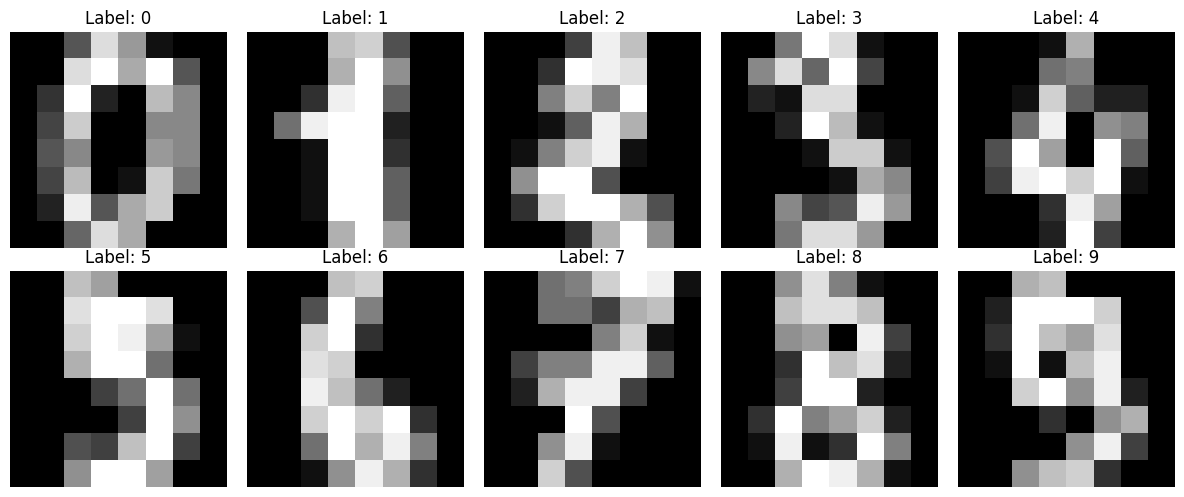

In [3]:
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(digits.images[i], cmap='gray')
    ax.set_title(f'Label: {y[i]}')
    ax.axis('off')
plt.tight_layout()
plt.show()

In [4]:
X_norm = X.astype('float32') / 16.0
X_train, X_test, y_train, y_test = train_test_split(X_norm, y, test_size=0.2, random_state=42)

---

## Baseline: PCA

Sebelum bikin autoencoder, kita apply PCA dulu sebagai baseline.

In [5]:
pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f'Explained Variance: {pca.explained_variance_ratio_}')
print(f'Total: {sum(pca.explained_variance_ratio_):.2%}')

Explained Variance: [0.14804542 0.13685748]
Total: 28.49%


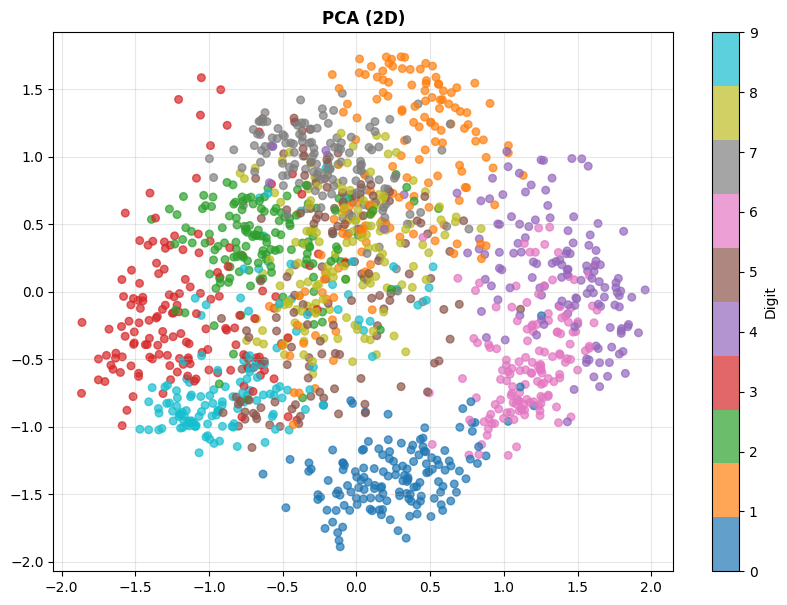

In [6]:
plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_train_pca[:, 0], X_train_pca[:, 1], c=y_train, cmap='tab10', alpha=0.7, s=30)
plt.colorbar(scatter, label='Digit')
plt.title('PCA (2D)', fontweight='bold')
plt.grid(True, alpha=0.3)
plt.show()

In [7]:
X_test_pca_recon = pca.inverse_transform(X_test_pca)
pca_mse = np.mean((X_test - X_test_pca_recon) ** 2)
pca_mse

np.float32(0.052217655)

---

## Autoencoder

Arsitektur: `64 -> 32 -> 16 -> 2 (bottleneck) -> 16 -> 32 -> 64`

In [8]:
input_img = Input(shape=(64,))

x = Dense(32, activation='relu')(input_img)
x = Dense(16, activation='relu')(x)
bottleneck = Dense(2, name='bottleneck')(x)

x = Dense(16, activation='relu')(bottleneck)
x = Dense(32, activation='relu')(x)
output_img = Dense(64, activation='sigmoid')(x)

autoencoder = Model(input_img, output_img)
encoder = Model(input_img, bottleneck)

autoencoder.compile(optimizer=Adam(0.001), loss='mse')
autoencoder.summary()

I0000 00:00:1774808795.673325      24 gpu_device.cc:2019] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 15511 MB memory:  -> device: 0, name: Tesla P100-PCIE-16GB, pci bus id: 0000:00:04.0, compute capability: 6.0


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bottleneck (Dense)              │ (None, 2)              │            34 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │            48 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 64)             │         2,112 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,346 (20.88 KB)

 Trainable params: 5,346 (20.88 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
history = autoencoder.fit(
    X_train, X_train,
    epochs=100, batch_size=64,
    validation_data=(X_test, X_test),
    verbose=1
)

Epoch 1/100


I0000 00:00:1774808798.505874      72 service.cc:152] XLA service 0x7886ac00c390 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1774808798.505907      72 service.cc:160]   StreamExecutor device (0): Tesla P100-PCIE-16GB, Compute Capability 6.0


I0000 00:00:1774808798.861962      72 cuda_dnn.cc:529] Loaded cuDNN version 91002



 1/23 ━━━━━━━━━━━━━━━━━━━━ 59s 3s/step - loss: 0.1817

I0000 00:00:1774808799.701876      72 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


...


 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - loss: 0.0391


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 0.0380 - val_loss: 0.0393


Epoch 100/100



 1/23 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 0.0373


23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0379 - val_loss: 0.0394


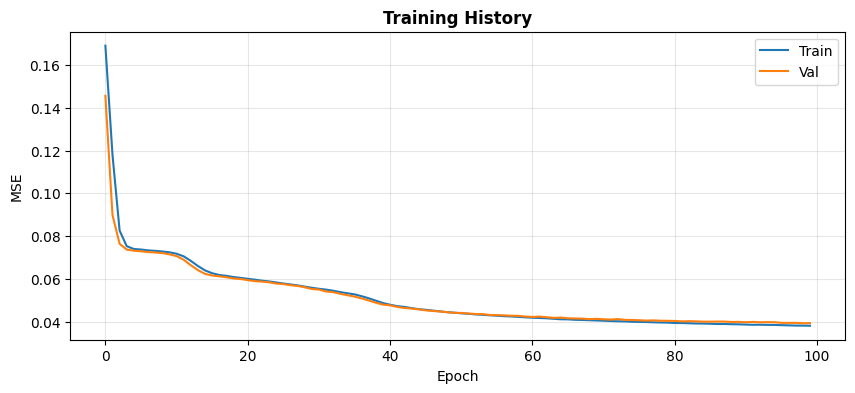

In [10]:
plt.figure(figsize=(10, 4))
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Training History', fontweight='bold')
plt.xlabel('Epoch')
plt.ylabel('MSE')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

### Extract Features

In [11]:
X_train_ae = encoder.predict(X_train)
X_test_ae = encoder.predict(X_test)

print(f'Original: {X_train.shape[1]}D -> Bottleneck: {X_train_ae.shape[1]}D ({X_train.shape[1]//X_train_ae.shape[1]}x compression)')


 1/45 ━━━━━━━━━━━━━━━━━━━━ 8s 197ms/step


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step



 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


Original: 64D -> Bottleneck: 2D (32x compression)


---

## Perbandingan: PCA vs Autoencoder

### Latent Space

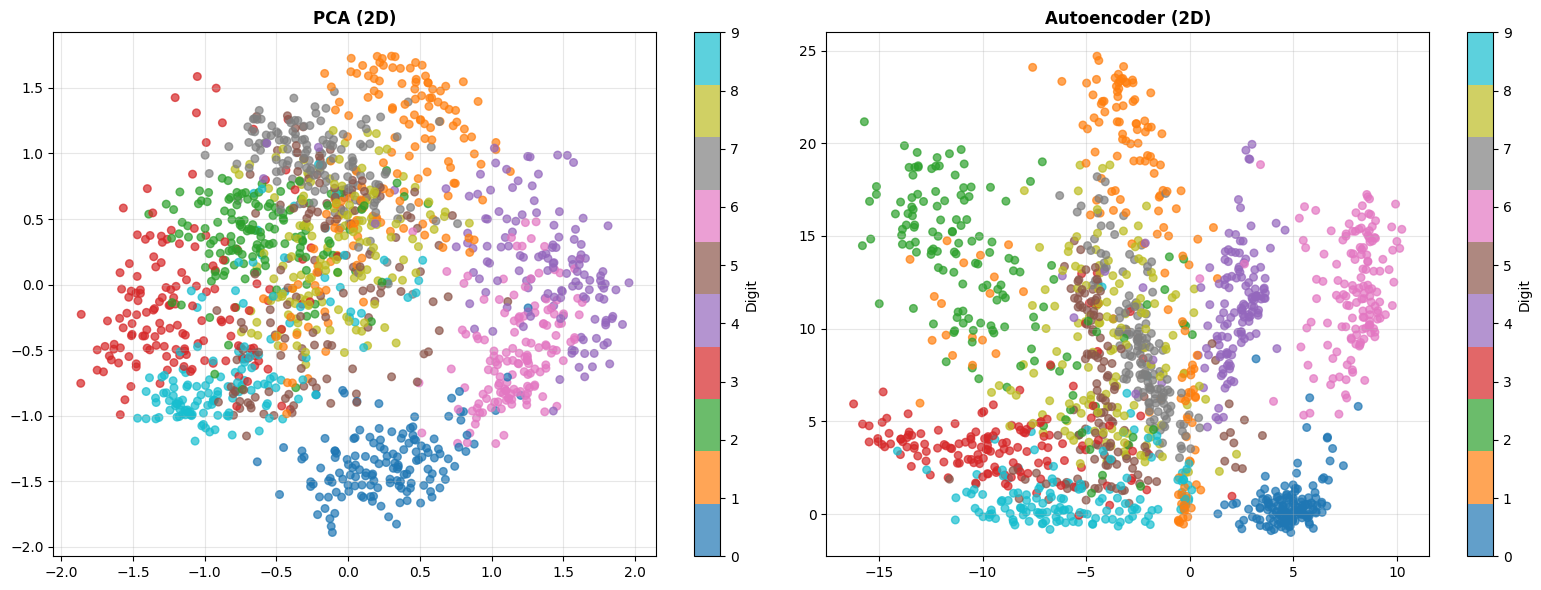

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, data, title in zip(axes, [X_train_pca, X_train_ae], ['PCA (2D)', 'Autoencoder (2D)']):
    s = ax.scatter(data[:, 0], data[:, 1], c=y_train, cmap='tab10', alpha=0.7, s=30)
    ax.set_title(title, fontweight='bold')
    ax.grid(True, alpha=0.3)
    plt.colorbar(s, ax=ax, label='Digit')

plt.tight_layout()
plt.show()

### Reconstruction: Original vs PCA vs Autoencoder


 1/12 ━━━━━━━━━━━━━━━━━━━━ 2s 246ms/step


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step 


12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 23ms/step


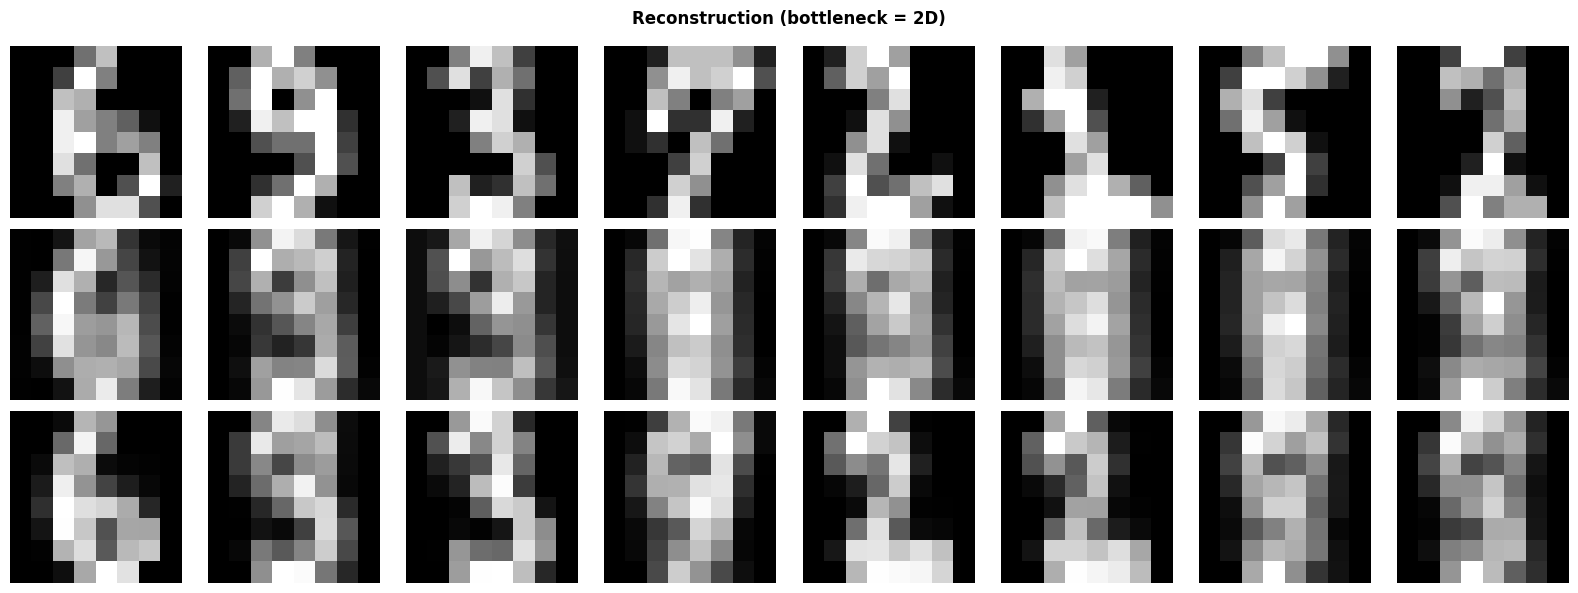

In [13]:
X_test_ae_recon = autoencoder.predict(X_test)
ae_mse = np.mean((X_test - X_test_ae_recon) ** 2)

n = 8
fig, axes = plt.subplots(3, n, figsize=(16, 6))

for i in range(n):
    axes[0, i].imshow(X_test[i].reshape(8, 8), cmap='gray')
    axes[1, i].imshow(X_test_pca_recon[i].reshape(8, 8), cmap='gray')
    axes[2, i].imshow(X_test_ae_recon[i].reshape(8, 8), cmap='gray')
    for row in range(3):
        axes[row, i].axis('off')

axes[0, 0].set_ylabel('Original', fontweight='bold', rotation=0, labelpad=70)
axes[1, 0].set_ylabel('PCA', fontweight='bold', rotation=0, labelpad=70)
axes[2, 0].set_ylabel('Autoencoder', fontweight='bold', rotation=0, labelpad=70)

plt.suptitle('Reconstruction (bottleneck = 2D)', fontweight='bold')
plt.tight_layout()
plt.show()

### Kuantitatif

In [14]:
lr = LogisticRegression(max_iter=1000, random_state=42)

lr.fit(X_train, y_train)
acc_orig = accuracy_score(y_test, lr.predict(X_test))

lr.fit(X_train_pca, y_train)
acc_pca = accuracy_score(y_test, lr.predict(X_test_pca))

lr.fit(X_train_ae, y_train)
acc_ae = accuracy_score(y_test, lr.predict(X_test_ae))

sil_pca = silhouette_score(X_train_pca, y_train)
sil_ae = silhouette_score(X_train_ae, y_train)

pd.DataFrame({
    'Metric': ['Dimensi', 'Recon MSE', 'Silhouette', 'Accuracy'],
    'Original': [64, '-', '-', f'{acc_orig:.2%}'],
    'PCA (2D)': [2, f'{pca_mse:.6f}', f'{sil_pca:.4f}', f'{acc_pca:.2%}'],
    'AE (2D)': [2, f'{ae_mse:.6f}', f'{sil_ae:.4f}', f'{acc_ae:.2%}']
})

,Metric,Original,PCA (2D),AE (2D)
0,Dimensi,64,2,2
1,Recon MSE,-,0.052218,0.039356
2,Silhouette,-,0.0917,0.1644
3,Accuracy,96.67%,64.44%,65.83%


---

## Eksperimen: Bottleneck Size

Bottleneck lebih besar = lebih banyak informasi dipertahankan, tapi kurang kompresi.

In [15]:
bn_sizes = [2, 5, 10, 20]
rows = []

for bn in bn_sizes:
    inp = Input(shape=(64,))
    enc = Dense(32, activation='relu')(inp)
    b = Dense(bn)(enc)
    dec = Dense(32, activation='relu')(b)
    out = Dense(64, activation='sigmoid')(dec)

    ae = Model(inp, out)
    enc_m = Model(inp, b)
    ae.compile(optimizer=Adam(0.001), loss='mse')
    ae.fit(X_train, X_train, epochs=100, batch_size=64, verbose=0)

    recon_err = np.mean((X_test - ae.predict(X_test)) ** 2)
    feats_tr, feats_te = enc_m.predict(X_train), enc_m.predict(X_test)

    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(feats_tr, y_train)
    acc = accuracy_score(y_test, lr.predict(feats_te))

    rows.append({'Bottleneck': bn, 'Recon MSE': recon_err, 'Accuracy': acc})

pd.DataFrame(rows)


 1/12 ━━━━━━━━━━━━━━━━━━━━ 2s 199ms/step


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step 


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step



 1/45 ━━━━━━━━━━━━━━━━━━━━ 6s 140ms/step


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  

...


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step



 1/12 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


,Bottleneck,Recon MSE,Accuracy
0,2,0.043424,0.600000
1,5,0.026589,0.875000
2,10,0.015792,0.927778
3,20,0.008915,0.961111


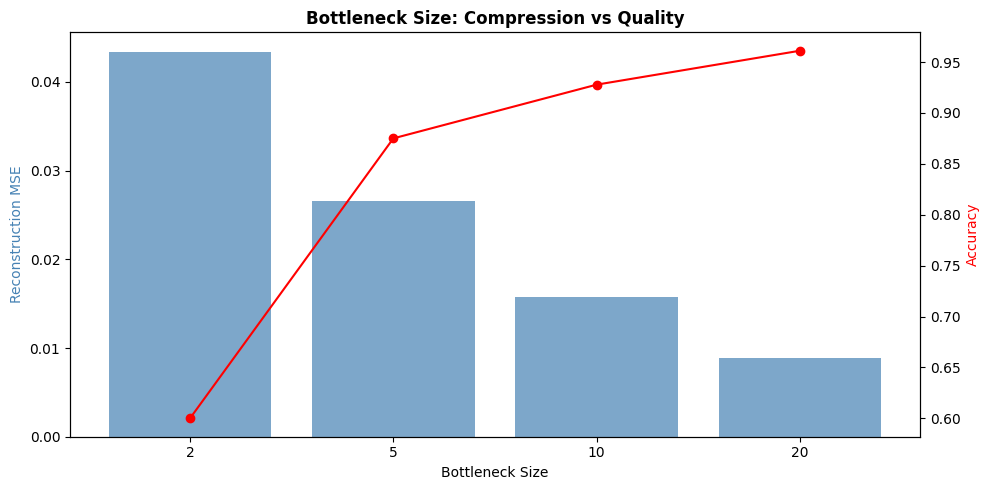

In [16]:
fig, ax1 = plt.subplots(figsize=(10, 5))

errs = [r['Recon MSE'] for r in rows]
accs = [r['Accuracy'] for r in rows]

ax1.bar(range(len(bn_sizes)), errs, alpha=0.7, color='steelblue')
ax1.set_ylabel('Reconstruction MSE', color='steelblue')
ax1.set_xticks(range(len(bn_sizes)))
ax1.set_xticklabels(bn_sizes)
ax1.set_xlabel('Bottleneck Size')

ax2 = ax1.twinx()
ax2.plot(range(len(bn_sizes)), accs, 'o-', color='red')
ax2.set_ylabel('Accuracy', color='red')

plt.title('Bottleneck Size: Compression vs Quality', fontweight='bold')
plt.tight_layout()
plt.show()

In [ ]:
# Save notebook with outputs
import shutil, glob
shutil.copy('__notebook__.ipynb', 'Autoencoders.ipynb')
print(f'Autoencoders.ipynb saved to output')

---

## Kesimpulan

- Autoencoder belajar reconstruct input — bottleneck berisi representasi kompresi.
- Bisa tangkap pola non-linear, tidak seperti PCA.
- Bottleneck size = trade-off antara kompresi dan kualitas.
- Tidak selalu lebih baik dari PCA — tergantung data dan arsitektur.
- Butuh data cukup dan tuning (epochs, lr, architecture).

---

*Referensi: Goodfellow et al. (2016). Deep Learning. MIT Press.*